# IDG_2026 S-1

# 1. Librerías

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify

1. Conexión a Base de Datos
Usamos SQLalchemy para crear un motor de conexión a PostgresSQL

In [2]:
DB_HOST     = 'localhost'
DB_PORT     = 5432
DB_NAME     = 'censo_v_2017'
DB_USER     = 'postgres'
DB_PASSWORD = 'postgres'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# 2. Carga de Datos

In [3]:
query_ej = '''
cmxn
egtr
'''

In [7]:
# Carga de polígonos comunales
sql_comunas = '''
SELECT nom_comuna, geom
FROM dpa.comunas_v
WHERE nom_provin = 'VALPARAÍSO'
AND nom_comuna != 'JUAN FERNÁNDEZ';
'''

gdf_comunas    = gpd.read_postgis(sql_comunas, engine, geom_col='geom')
gdf_centroides = gdf_comunas.copy()
gdf_centroides['geometry'] = gdf_comunas.centroid

print(f'Comunas: {len(gdf_comunas)}')
display(gdf_comunas)

Comunas: 6


C:\Users\DIGEA\AppData\Local\Temp\ipykernel_18908\3665287693.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroides['geometry'] = gdf_comunas.centroid


,nom_comuna,geom
0,VIÑA DEL MAR,"MULTIPOLYGON (((-71.54606 -32.94593, -71.54604..."
1,CONCÓN,"MULTIPOLYGON (((-71.49819 -32.91575, -71.49776..."
2,PUCHUNCAVÍ,"MULTIPOLYGON (((-71.41383 -32.63012, -71.41364..."
3,QUINTERO,"MULTIPOLYGON (((-71.54524 -32.792, -71.54526 -..."
4,CASABLANCA,"MULTIPOLYGON (((-71.69488 -33.1558, -71.69454 ..."
5,VALPARAÍSO,"MULTIPOLYGON (((-71.702 -33.15481, -71.70205 -..."


In [9]:
sql_indicadores = '''
WITH agg AS
(SELECT c.nom_comuna, z.geocodigo::double precision AS geocodigo, COUNT(*) AS "total viviendas", COUNT(*) FILTER(WHERE v.p03b >= 3 and v.p03b <=6) AS "techos precarios", 
ROUND(((COUNT(*) FILTER(WHERE v.p03b >= 3 and v.p03b <=6))*100.0)/COUNT(*),2) AS "tasa de techos precarios", 
ROUND((COUNT(*) FILTER(WHERE p.p12pais >998)*100.0/COUNT(*)), 2) AS "porcentaje de migrantes"
FROM public.personas AS p
JOIN public.hogares AS h
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'VALPARAÍSO' AND c.nom_comuna != 'JUAN FERNÁNDEZ'
GROUP BY z.geocodigo, c.nom_comuna
ORDER BY geocodigo, "porcentaje de migrantes"
)


SELECT g.*, shp.geom
FROM agg AS g
JOIN dpa.zonas_censales_v AS shp ON shp.geocodigo = g.geocodigo
WHERE g.geocodigo != '5101242001';
'''

<Axes: >

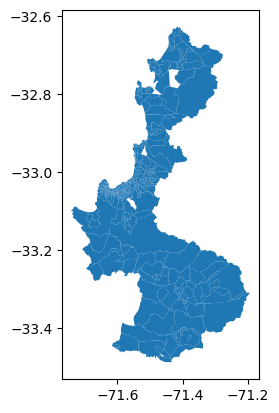

In [11]:
gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')
gdf.plot()

<Axes: >

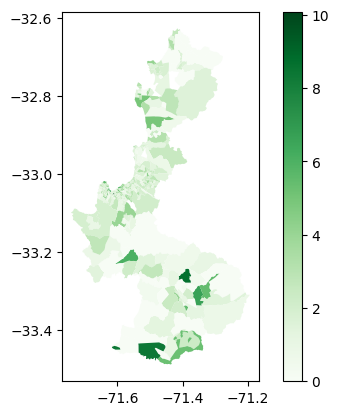

In [15]:
gdf.plot(column='porcentaje de migrantes',
        cmap='Greens',
        legend = 'True')

In [ ]:
# 3. EDA
## 3.1 Estadísticos Descriptivos

In [16]:
gdf[['porcentaje de migrantes', 'tasa de techos precarios']].describe().round(2)

,porcentaje de migrantes,tasa de techos precarios
count,412.00,412.00
mean,1.82,64.42
std,1.39,25.55
min,0.00,0.48
25%,0.99,47.64
50%,1.57,72.45
75%,2.41,85.74
max,10.09,100.00


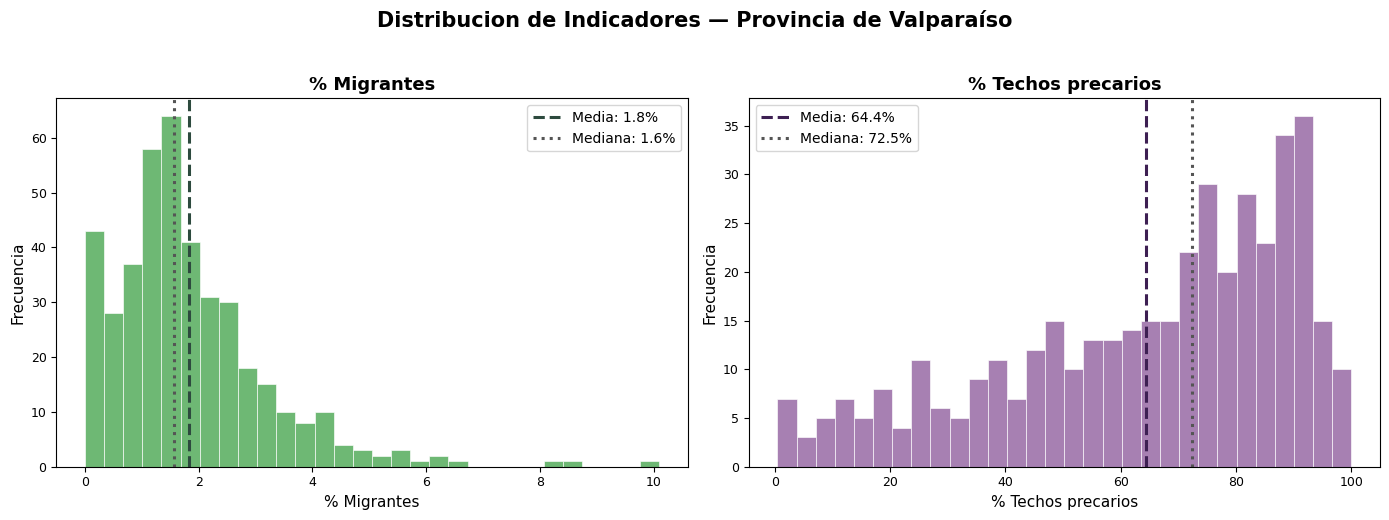

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Distribucion de Indicadores — Provincia de Valparaíso',
             fontsize=15, fontweight='bold', y=1.03)

vars_config = [
    ('porcentaje de migrantes',    '#5aae61', '#2d4a3e', '% Migrantes'),
    ('tasa de techos precarios', '#9b6fa8', '#3d1f52', '% Techos precarios'),
]

for ax, (col, color, color_dark, label) in zip(axes, vars_config):
    datos = gdf[col].dropna()
    ax.hist(datos, bins=30, color=color, edgecolor='white', linewidth=0.5, alpha=0.88)
    ax.axvline(datos.mean(),   color=color_dark, ls='--', lw=2.2,
               label=f'Media: {datos.mean():.1f}%')
    ax.axvline(datos.median(), color='#555',     ls=':',  lw=2.2,
               label=f'Mediana: {datos.median():.1f}%')
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.legend(fontsize=10)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

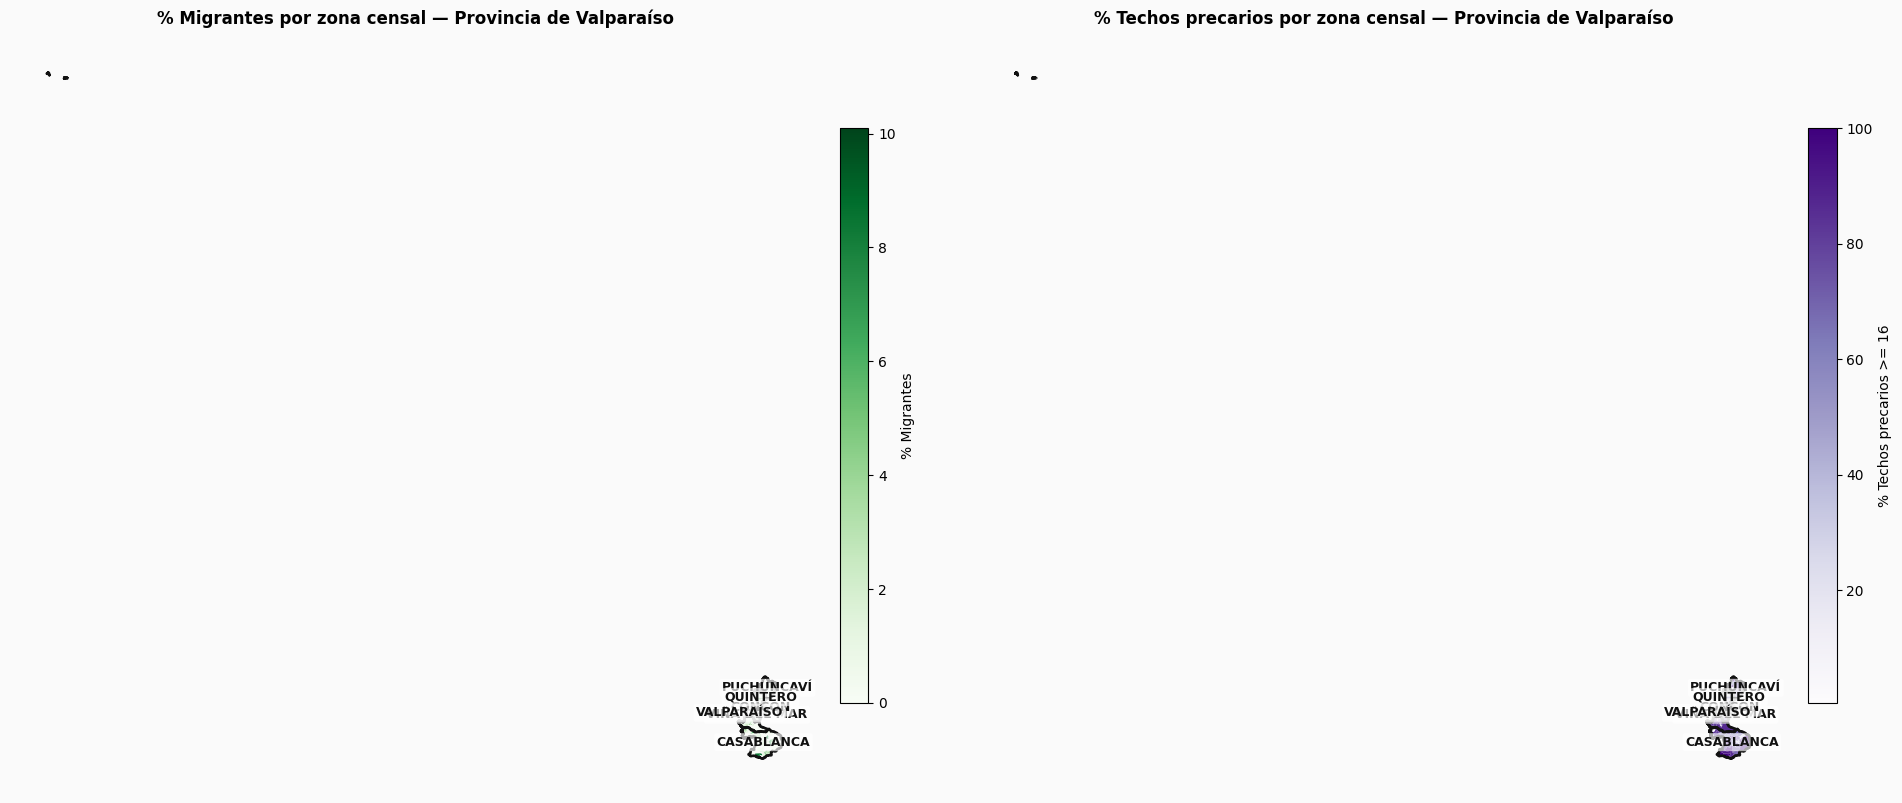

In [21]:
def plot_univariado(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['nom_comuna'],
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

plot_univariado(
    axes[0], gdf, gdf_comunas, gdf_centroides,
    'porcentaje de migrantes', 'Greens',
    '% Migrantes por zona censal — Provincia de Valparaíso',
    '% Migrantes'
)
plot_univariado(
    axes[1], gdf, gdf_comunas, gdf_centroides,
    'tasa de techos precarios', 'Purples',
    '% Techos precarios por zona censal — Provincia de Valparaíso',
    '% Techos precarios >= 16'
)

plt.tight_layout(pad=2)
plt.show()

In [22]:
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

NameError: name 'gdf_bi' is not defined

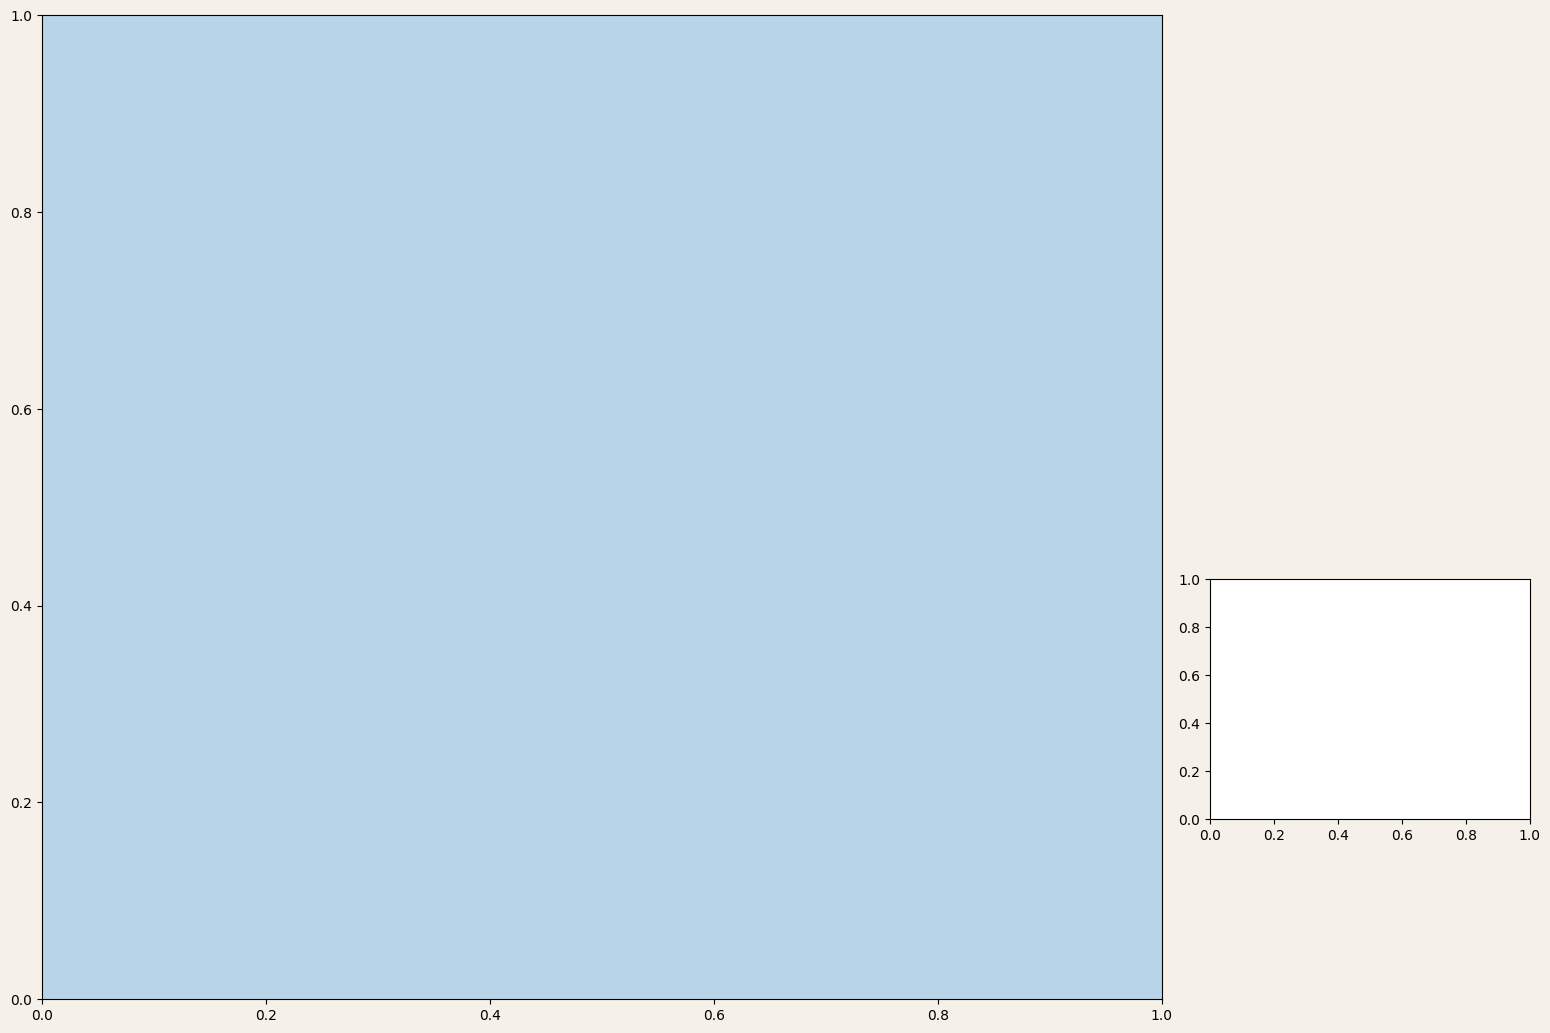

In [23]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# ── Figura y layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa: izquierda 70%
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda: esquina derecha

# ── Mapa ─────────────────────────────────────────────────────────────────────
ax_map.set_facecolor('#b8d4e8')         # azul suave

# Zonas censales
gdf_bi.plot(
    color=gdf_bi['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

# Limites comunales: linea gruesa y oscura
gdf_comunas.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

# Etiquetas con stroke blanco 
for _, row in gdf_centroides.iterrows():
    txt = ax_map.annotate(
        row['nom_comuna'],
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

# Marco del mapa: borde fino gris
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

# ── Bloque de titulos (espacio figura) ──
fig.text(0.37, 0.965, 'MAPA BIVARIADO', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Migrantes  x  % Escolaridad >=16 anos', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Valparaíso  .  Zonas Censales  .  Censo 2017',
         ha='center', fontsize=9.5, color='#777')

# Linea separadora bajo el titulo
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

# Fuente (pie de figura)
fig.text(0.02, 0.017, 'Fuente: Censo 2017, INE Chile',
         ha='left', fontsize=8, color='#999', style='italic')

# ── Leyenda bivariada ───
# Estilo del axes de leyenda: fondo blanco con borde gris
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Migrantes  →',
    ylab='% Techos precarios  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()